**END-TO-END AI FOR SCIENCE · CRASH SIMULATION TRACK**

# Notebook0: Native VTP Data Contract and Preprocessing

**Executed PhysicsNeMo analysis · 129 training simulations · 5 validation simulations · full 13,675-point mesh**

The supplied bumper-beam dataset is already in the native VTP format consumed by the
PhysicsNeMo crash recipe. Its reference coordinates, displacement history, physical fields,
topology, split membership, and conditioning values are audited before constructing the exact
tensors used by Notebook1 and Notebook2.

New source simulations can be generated with PhysicsNeMo's [OpenRadioss dataset-generation recipe](https://github.com/NVIDIA/physicsnemo/tree/main/examples/structural_mechanics/openradioss_dataset_gen), specifically its [bumper-beam flow](https://github.com/NVIDIA/physicsnemo/tree/main/examples/structural_mechanics/openradioss_dataset_gen/bumper_beam). That flow creates `d3plot` runs and run-level metadata that PhysicsNeMo-Curator can convert to VTP.

> This notebook reads the supplied VTP and JSON files without changing them. It does not create synthetic data or make a new split.


## Bumper-beam impact

This solver visualization provides physical context for the data contract examined below:
the deformable bumper beam interacts with the barrier while its shape changes through time.

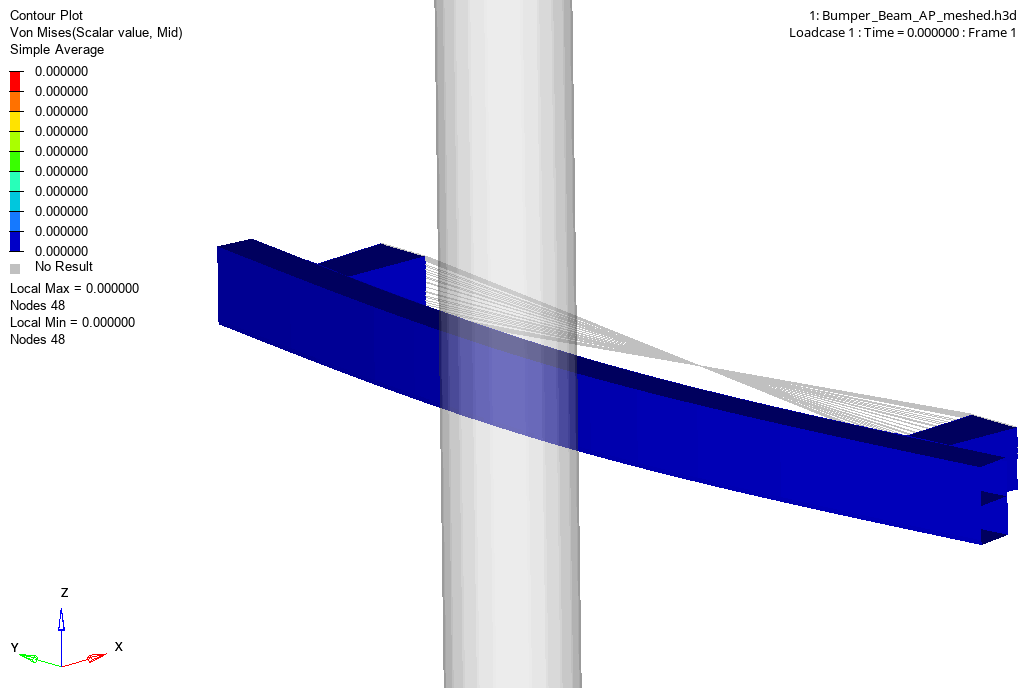


## Workflow components

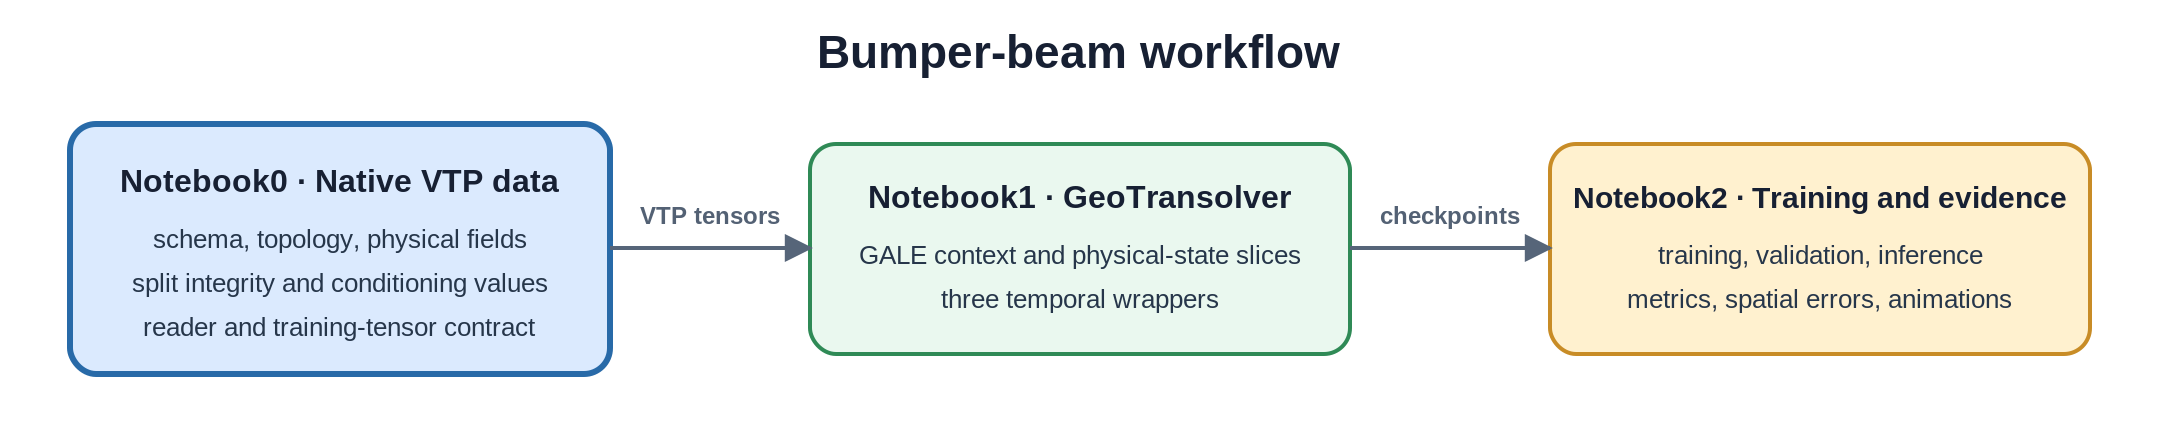

Notebook0 establishes the data contract, Notebook1 traces that contract through GeoTransolver,
and Notebook2 executes training, validation, inference, and comparison.


## 1. Runtime and source data

The mounted PhysicsNeMo recipe and bumper-beam dataset are discovered from the current working
directory or configured with environment variables. This notebook reads the source data, derives
its training statistics, and does not require a historical run directory or checkpoint.


In [1]:
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
from IPython.display import Image, display
from time import perf_counter
from tempfile import TemporaryDirectory
import hashlib, json, os, re, sys, warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pyvista as pv
import torch
import physicsnemo

def locate_recipe():
    candidates = []
    configured_recipe = os.environ.get("PHYSICSNEMO_CRASH_RECIPE")
    configured_root = os.environ.get("CRASH_PROJECT_ROOT")
    if configured_recipe:
        candidates.append(Path(configured_recipe).expanduser())
    if configured_root:
        candidates.append(
            Path(configured_root).expanduser()
            / "physicsnemo/examples/structural_mechanics/crash"
        )
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidates.append(base / "physicsnemo/examples/structural_mechanics/crash")
    for candidate in candidates:
        if (candidate / "train.py").is_file() and (candidate / "vtp_reader.py").is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        "PhysicsNeMo crash recipe not found. Set PHYSICSNEMO_CRASH_RECIPE or CRASH_PROJECT_ROOT."
    )

def locate_dataset():
    candidates = []
    configured = os.environ.get("BUMPER_BEAM_DATA_ROOT")
    if configured:
        candidates.append(Path(configured).expanduser())
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidates.extend([base / "datasets/bumper_beam", base / "data/bumper_beam"])
    candidates.append(Path("/workspace/datasets/bumper_beam"))
    for candidate in candidates:
        if (candidate / "train").is_dir() and (candidate / "validation").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Bumper-beam dataset not found. Set BUMPER_BEAM_DATA_ROOT before starting Jupyter."
    )


RECIPE_DIR = locate_recipe()
DATA_ROOT = locate_dataset()

sys.path.insert(0, str(RECIPE_DIR))
from vtp_reader import load_vtp_file, build_edges_from_mesh_connectivity

required = [
    DATA_ROOT / "global_features.json", DATA_ROOT / "train",
    DATA_ROOT / "validation", DATA_ROOT / "test",
    RECIPE_DIR / "vtp_reader.py", RECIPE_DIR / "datapipe.py",
]
for path in required:
    assert path.exists(), path

def package_version(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return "not installed"

print(f"Python      : {sys.version.split()[0]}")
print(f"PhysicsNeMo : {getattr(physicsnemo, '__version__', package_version('nvidia-physicsnemo'))}")
print(f"PyTorch     : {torch.__version__}")
print(f"PyVista     : {pv.__version__}")
print("Recipe      : crash/train.py and crash/vtp_reader.py found")
print("Dataset     : train, validation, test, and global_features.json found")


Python      : 3.12.3
PhysicsNeMo : 2.2.0
PyTorch     : 2.13.0a0+9186a08b2c.nv26.07
PyVista     : 0.48.4
Recipe      : crash/train.py and crash/vtp_reader.py found
Dataset     : train, validation, test, and global_features.json found


## 2. Supplied split and conditioning integrity

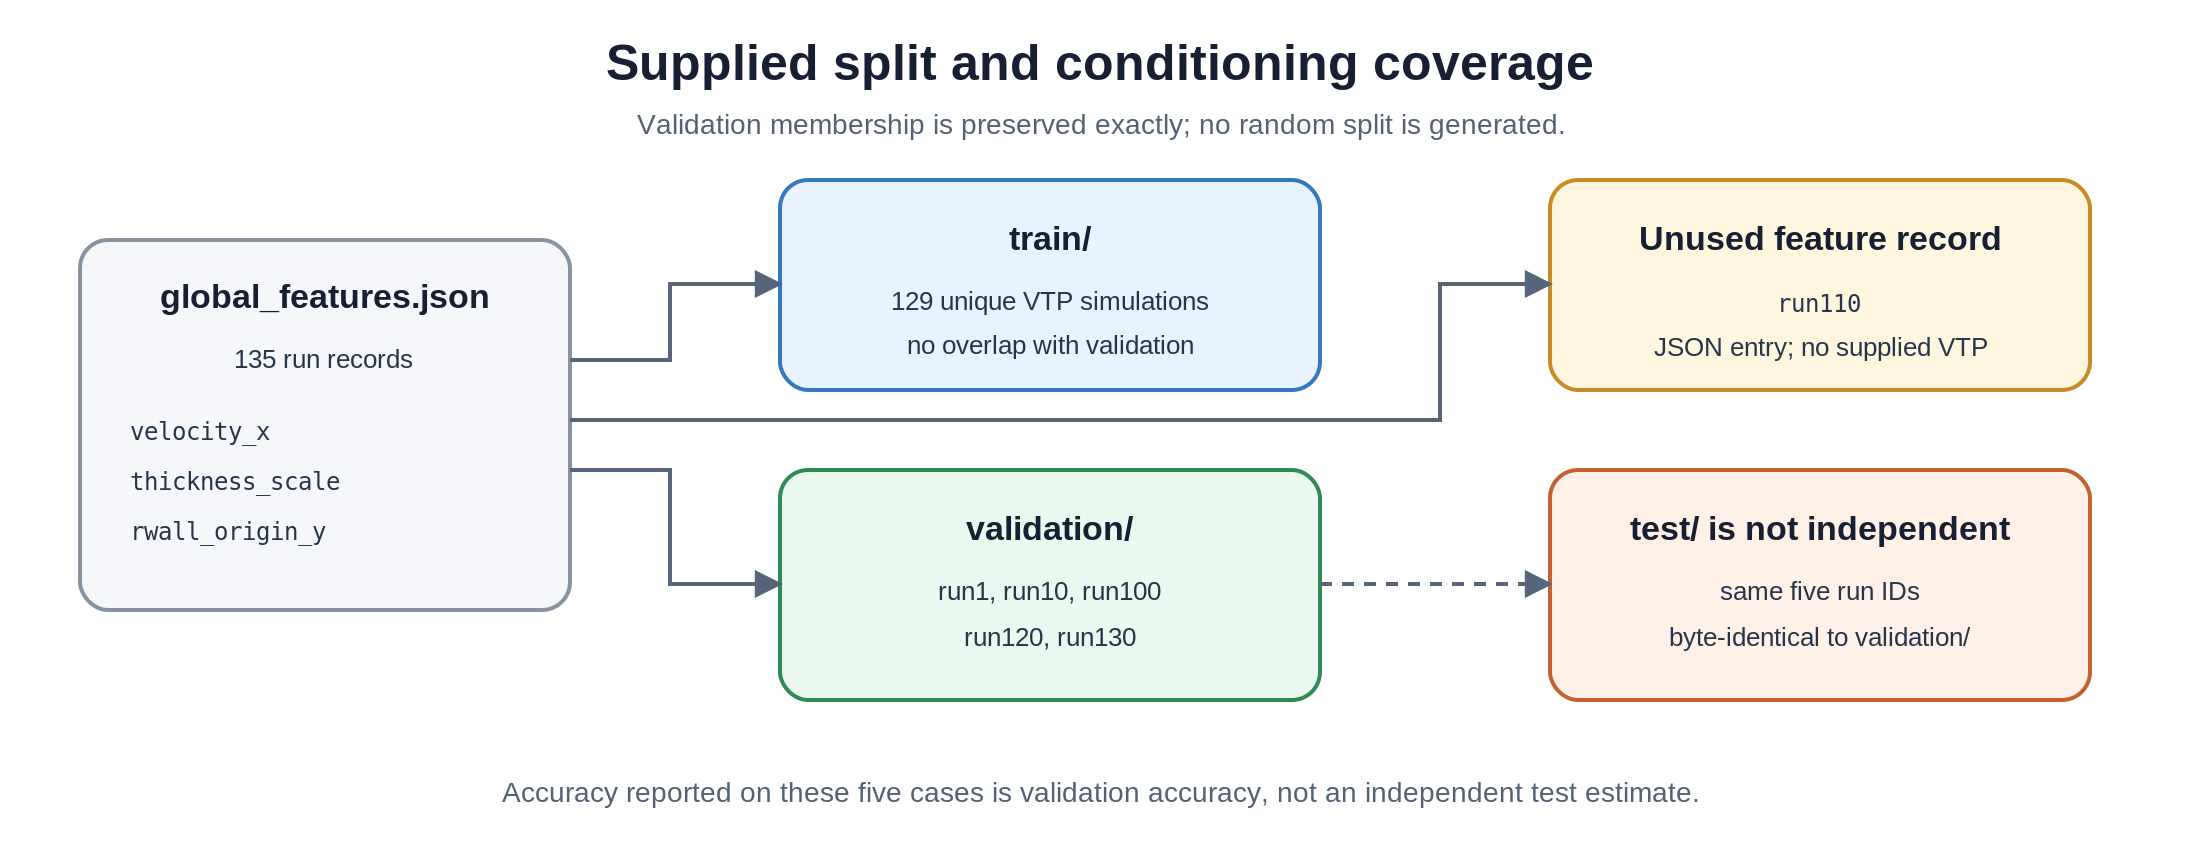

Split membership is preserved exactly. SHA-256 checks distinguish an independent holdout from
a copied directory rather than relying only on matching filenames.


In [2]:
def natural_run_key(path):
    match = re.search(r"(\d+)$", Path(path).stem)
    return int(match.group(1)) if match else Path(path).stem

def sha256sum(path, chunk_size=2**20):
    digest = hashlib.sha256()
    with open(path, "rb") as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

train_files = sorted((DATA_ROOT / "train").glob("*.vtp"), key=natural_run_key)
validation_files = sorted((DATA_ROOT / "validation").glob("*.vtp"), key=natural_run_key)
test_files = sorted((DATA_ROOT / "test").glob("*.vtp"), key=natural_run_key)
global_records = json.loads((DATA_ROOT / "global_features.json").read_text())

train_ids = {p.stem for p in train_files}
validation_ids = {p.stem for p in validation_files}
test_ids = {p.stem for p in test_files}
supplied_ids = train_ids | validation_ids

assert len(train_files) == 129 and len(validation_files) == len(test_files) == 5
assert train_ids.isdisjoint(validation_ids)
assert validation_ids == test_ids
assert supplied_ids <= global_records.keys()

duplicate_rows = []
for validation_path, test_path in zip(validation_files, test_files):
    validation_hash = sha256sum(validation_path)
    test_hash = sha256sum(test_path)
    duplicate_rows.append([validation_path.stem, validation_hash[:12], test_hash[:12],
                           validation_hash == test_hash])
duplicate_table = pd.DataFrame(
    duplicate_rows, columns=["run", "validation SHA-256", "test SHA-256", "byte-identical"])
assert duplicate_table["byte-identical"].all()

extra_feature_ids = sorted(set(global_records) - supplied_ids, key=lambda x: int(x[3:]))
manifest = pd.DataFrame([
    ["train", len(train_files), "model fitting", "unique VTP files"],
    ["validation", len(validation_files), "model selection", ", ".join(sorted(validation_ids, key=lambda x: int(x[3:])) )],
    ["test", len(test_files), "validation alias", "byte-identical copy"],
    ["global features", len(global_records), "conditioning records", f"extra: {', '.join(extra_feature_ids)}"],
], columns=["source", "count", "role", "integrity result"])
display(manifest)
display(duplicate_table)
print(f"Unique train + validation simulations: {len(supplied_ids)}")
print(f"JSON entries without a supplied VTP : {extra_feature_ids}")


,source,count,role,integrity result
0,train,129,model fitting,unique VTP files
1,validation,5,model selection,"run1, run10, run100, run120, run130"
2,test,5,validation alias,byte-identical copy
3,global features,135,conditioning records,extra: run110


,run,validation SHA-256,test SHA-256,byte-identical
0,run1,0498128db9a2,0498128db9a2,True
1,run10,ca10abf3170e,ca10abf3170e,True
2,run100,308adce959da,308adce959da,True
3,run120,6dff1b19df7b,6dff1b19df7b,True
4,run130,3a042cf9cfe2,3a042cf9cfe2,True


Unique train + validation simulations: 134
JSON entries without a supplied VTP : ['run110']


,training minimum,training maximum,unique values
velocity_x,-7.0,-3.0,3.0
thickness_scale,0.7,1.3,3.0
rwall_origin_y,0.0,240.0,3.0


,velocity_x,thickness_scale,rwall_origin_y
validation run,,,
run1,-5.0,1.0,0.0
run10,-3.0,1.0,0.0
run100,-7.0,1.0,0.0
run120,-3.0,1.0,240.0
run130,-7.0,0.7,0.0


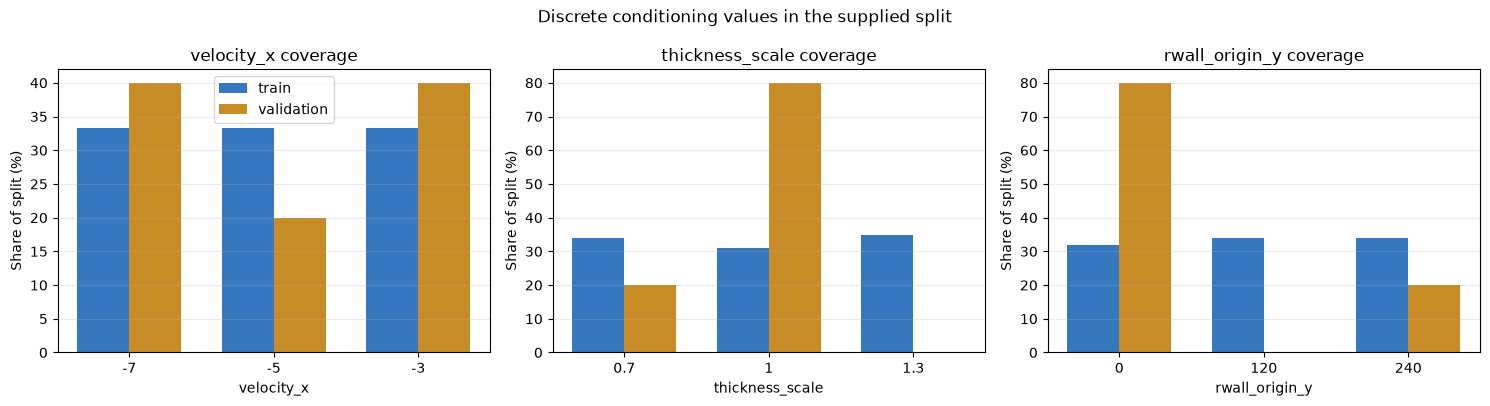

In [3]:
features = pd.DataFrame.from_dict(global_records, orient="index")
train_features = features.loc[sorted(train_ids, key=lambda x: int(x[3:]))]
validation_features = features.loc[sorted(validation_ids, key=lambda x: int(x[3:]))]

feature_ranges = train_features.agg(["min", "max", "nunique"]).T
feature_ranges.columns = ["training minimum", "training maximum", "unique values"]
display(feature_ranges)
display(validation_features.rename_axis("validation run"))

feature_names = ["velocity_x", "thickness_scale", "rwall_origin_y"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.1))
for ax, feature in zip(axes, feature_names):
    values = sorted(features[feature].unique())
    x = np.arange(len(values))
    train_share = train_features[feature].value_counts().reindex(values, fill_value=0) / len(train_features) * 100
    val_share = validation_features[feature].value_counts().reindex(values, fill_value=0) / len(validation_features) * 100
    ax.bar(x - 0.18, train_share, width=0.36, label="train", color="#3678bf")
    ax.bar(x + 0.18, val_share, width=0.36, label="validation", color="#c88c26")
    ax.set(xticks=x, xticklabels=[f"{v:g}" for v in values], xlabel=feature,
           ylabel="Share of split (%)", title=f"{feature} coverage")
    ax.grid(axis="y", alpha=0.25)
axes[0].legend()
fig.suptitle("Discrete conditioning values in the supplied split")
fig.tight_layout()
plt.show()


## 3. One VTP contains mesh, motion, and physical-field histories

A VTP file stores one simulation. Reference coordinates and quad topology occur once;
displacement, effective plastic strain (PEEQ), and von-Mises stress are indexed by physical
time from `0.000` to `0.250 s` in `0.005 s` increments.


In [4]:
def names_by_time(container, prefix):
    names = [name for name in container.keys() if name.startswith(prefix)]
    return sorted(names, key=lambda name: float(name.rsplit("t", 1)[1]))

sample_path = DATA_ROOT / "validation/run1.vtp"
raw_mesh = pv.read(sample_path)
displacement_names = names_by_time(raw_mesh.point_data, "displacement_t")
peeq_cell_names = names_by_time(raw_mesh.cell_data, "cell_effective_plastic_strain_t")
stress_cell_names = names_by_time(raw_mesh.cell_data, "cell_stress_vm_t")
times = np.array([float(name.rsplit("t", 1)[1]) for name in displacement_names])

cell_sizes, cursor = [], 0
faces = np.asarray(raw_mesh.faces)
while cursor < len(faces):
    size = int(faces[cursor])
    cell_sizes.append(size)
    cursor += size + 1

assert raw_mesh.n_points == 13675 and raw_mesh.n_cells == 13626
assert set(cell_sizes) == {4}
assert len(displacement_names) == len(peeq_cell_names) == len(stress_cell_names) == 51
assert np.allclose(np.diff(times), 0.005)

anatomy = pd.DataFrame([
    ["Points", "reference coordinates", tuple(raw_mesh.points.shape), str(raw_mesh.points.dtype)],
    ["PointData", "thickness", tuple(np.asarray(raw_mesh.point_data["thickness"]).shape), str(np.asarray(raw_mesh.point_data["thickness"]).dtype)],
    ["PointData", "51 displacement_t* vectors", tuple(np.asarray(raw_mesh.point_data[displacement_names[0]]).shape), str(np.asarray(raw_mesh.point_data[displacement_names[0]]).dtype)],
    ["CellData", "51 cell_effective_plastic_strain_t* scalars", tuple(np.asarray(raw_mesh.cell_data[peeq_cell_names[0]]).shape), str(np.asarray(raw_mesh.cell_data[peeq_cell_names[0]]).dtype)],
    ["CellData", "51 cell_stress_vm_t* scalars", tuple(np.asarray(raw_mesh.cell_data[stress_cell_names[0]]).shape), str(np.asarray(raw_mesh.cell_data[stress_cell_names[0]]).dtype)],
    ["Polys", "quad connectivity", (raw_mesh.n_cells, 4), str(faces.dtype)],
], columns=["VTP section", "content", "shape per array", "dtype"])
display(anatomy)
print(f"File             : {sample_path.name} ({sample_path.stat().st_size / 2**20:.2f} MiB)")
print(f"Point/Cell arrays: {len(raw_mesh.point_data)} / {len(raw_mesh.cell_data)}")
print(f"Physical time    : {times[0]:.3f} ... {times[-1]:.3f} s; dt={np.diff(times)[0]:.3f} s")


,VTP section,content,shape per array,dtype
0,Points,reference coordinates,"(13675, 3)",float64
1,PointData,thickness,"(13675,)",float64
2,PointData,51 displacement_t* vectors,"(13675, 3)",float64
3,CellData,51 cell_effective_plastic_strain_t* scalars,"(13626,)",float64
4,CellData,51 cell_stress_vm_t* scalars,"(13626,)",float64
5,Polys,quad connectivity,"(13626, 4)",int64


File             : run1.vtp (18.30 MiB)
Point/Cell arrays: 52 / 102
Physical time    : 0.000 ... 0.250 s; dt=0.005 s


,field at t=0.250 s,spatial mean,spatial maximum,reported units
0,displacement magnitude,149.148590,264.283555,native length units
1,effective plastic strain,0.006495,0.429461,source units
2,von-Mises stress,0.078781,0.413705,source units


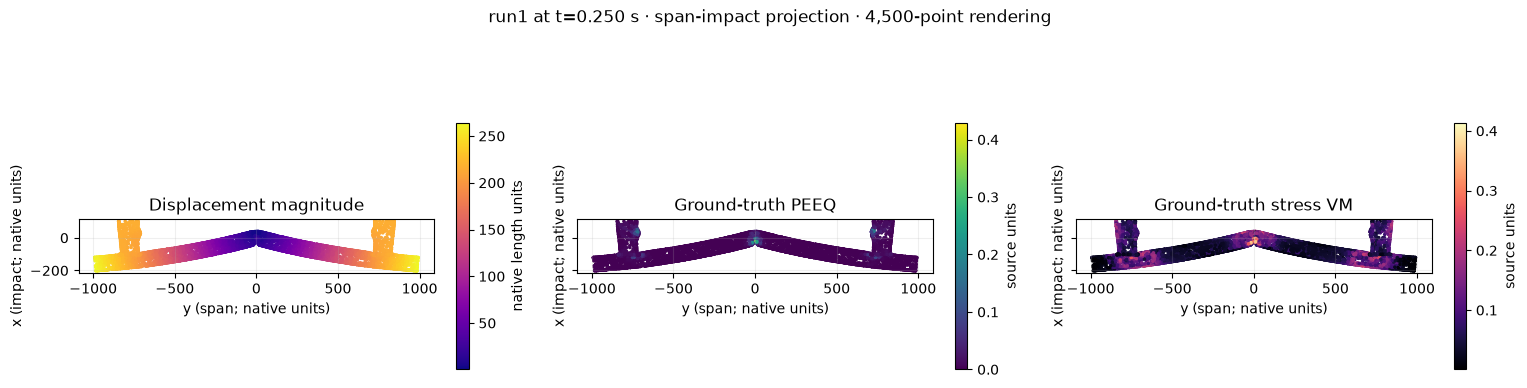

In [5]:
reference = np.asarray(raw_mesh.points, dtype=np.float64)
displacement = np.stack(
    [np.asarray(raw_mesh.point_data[name], dtype=np.float64) for name in displacement_names])
positions = reference[None, :, :] + displacement

converted = raw_mesh.cell_data_to_point_data(pass_cell_data=True)
peeq_point = np.stack(
    [np.asarray(converted.point_data[name], dtype=np.float64) for name in peeq_cell_names])
stress_point = np.stack(
    [np.asarray(converted.point_data[name], dtype=np.float64) for name in stress_cell_names])
displacement_magnitude = np.linalg.norm(positions - positions[0], axis=2)

assert positions.shape == (51, 13675, 3)
assert peeq_point.shape == stress_point.shape == (51, 13675)
assert np.allclose(displacement[0], 0.0)
assert all(np.isfinite(a).all() for a in (positions, peeq_point, stress_point))

final_fields = pd.DataFrame([
    ["displacement magnitude", displacement_magnitude[-1].mean(), displacement_magnitude[-1].max(), "native length units"],
    ["effective plastic strain", peeq_point[-1].mean(), peeq_point[-1].max(), "source units"],
    ["von-Mises stress", stress_point[-1].mean(), stress_point[-1].max(), "source units"],
], columns=["field at t=0.250 s", "spatial mean", "spatial maximum", "reported units"])
display(final_fields)

render_ids = np.sort(np.random.default_rng(7).choice(raw_mesh.n_points, 4500, replace=False))
final_xyz = positions[-1]
span = final_xyz[:, 1]
impact = final_xyz[:, 0]
panels = [
    (displacement_magnitude[-1], "Displacement magnitude", "native length units", "plasma"),
    (peeq_point[-1], "Ground-truth PEEQ", "source units", "viridis"),
    (stress_point[-1], "Ground-truth stress VM", "source units", "magma"),
]
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6), sharex=True, sharey=True)
for ax, (values, title, label, cmap) in zip(axes, panels):
    sc = ax.scatter(span[render_ids], impact[render_ids], c=values[render_ids], s=2.4, cmap=cmap,
                    vmin=float(values.min()), vmax=float(values.max()))
    ax.set(xlabel="y (span; native units)", ylabel="x (impact; native units)", title=title)
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
    fig.colorbar(sc, ax=ax, shrink=0.62, label=label)
fig.suptitle("run1 at t=0.250 s · span-impact projection · 4,500-point rendering")
fig.tight_layout()
plt.show()


## 4. Time alignment and physical-field evolution

The model receives state 0 as the reference input. Its 50 targets correspond to source states
1 through 50: the first target is `0.005 s`, and the last target is `0.250 s`. For the
time-conditioned model, query index $k=0,\ldots,49$ selects source state $k+1$, while the
dimensionless model-time input is $\tau_k=k/50$. Thus $\tau$ spans `0.00 ... 0.98`; it is not
physical time in seconds and does not reach `1.0`.


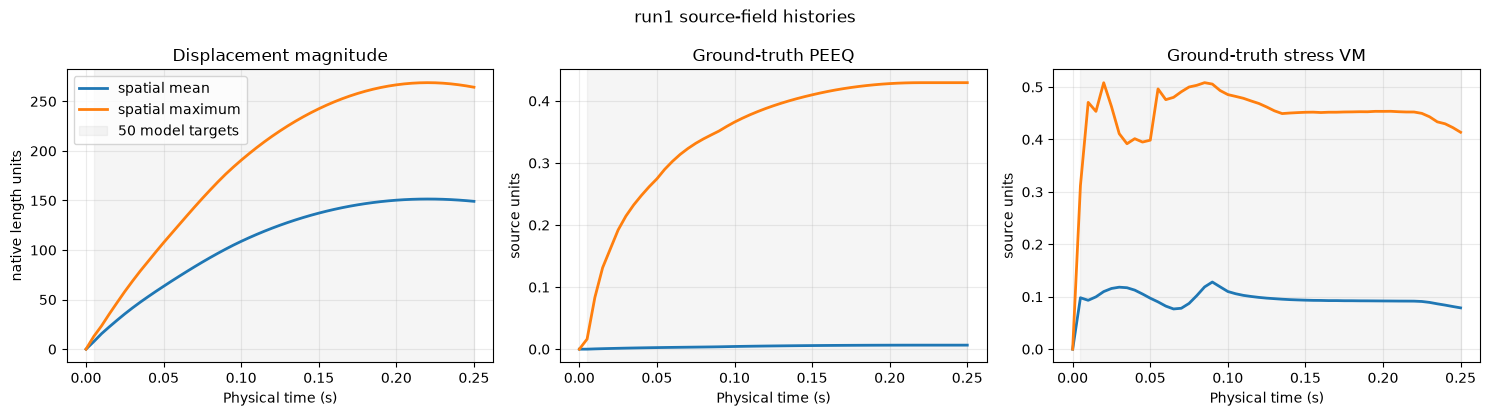

In [6]:
histories = [
    (displacement_magnitude, "Displacement magnitude", "native length units"),
    (peeq_point, "Ground-truth PEEQ", "source units"),
    (stress_point, "Ground-truth stress VM", "source units"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (values, title, unit) in zip(axes, histories):
    ax.plot(times, values.mean(axis=1), label="spatial mean", linewidth=2)
    ax.plot(times, values.max(axis=1), label="spatial maximum", linewidth=2)
    ax.axvspan(0.005, 0.250, color="0.5", alpha=0.08, label="50 model targets")
    ax.set(xlabel="Physical time (s)", ylabel=unit, title=title)
    ax.grid(alpha=0.25)
axes[0].legend()
fig.suptitle("run1 source-field histories")
fig.tight_layout()
plt.show()


## 5. Full train-and-validation schema audit

Every unique training and validation VTP is opened. The audit checks topology, time series,
finite final-state arrays, point thickness, and the presence of matching global features.


Audited  25/134 VTP files


Audited  50/134 VTP files


Audited  75/134 VTP files


Audited 100/134 VTP files


Audited 125/134 VTP files


Audited 134/134 VTP files


,runs,points,cells,median_file_MiB,max_final_displacement,max_final_PEEQ,max_final_stress
split,,,,,,,
train,129,13675,13626,18.292004,670.392701,1.344996,0.763936
validation,5,13675,13626,18.299186,605.715450,0.842113,0.585310


,geometry variant,VTP count,first run,last run,x span,y span,z span,validation members
0,1,27,1,27,357.598022,2023.734497,150.001732,"run1, run10"
1,2,27,28,54,357.598022,1011.867249,150.001732,-
2,3,27,55,81,357.598022,2023.734497,75.000866,-
3,4,27,82,108,357.598022,4047.468994,150.001732,run100
4,5,26,109,135,357.598022,2023.734497,300.003464,"run120, run130"


Schema audit duration : 38.2 s
Unique topology hashes: 1
Reference geometries  : 5 (shared topology)
Point thickness range : 0 ... 0 in all 134 files


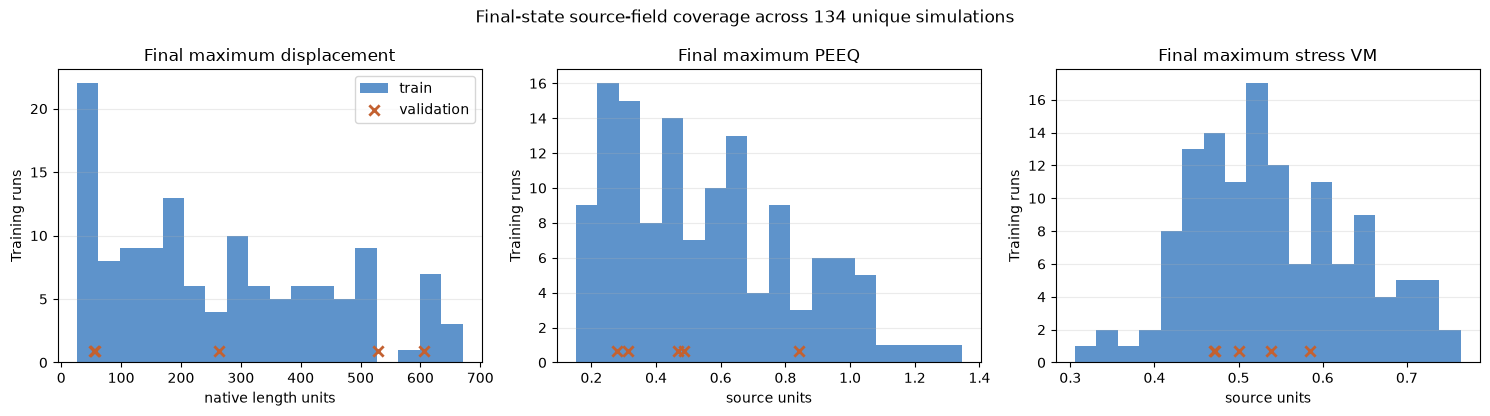

In [7]:
audit_rows = []
unique_files = [("train", p) for p in train_files] + [("validation", p) for p in validation_files]
train_moments = {
    name: np.zeros(3, dtype=np.float64)
    for name in ["pos_mean", "pos_meansq", "vel_mean", "vel_meansq", "acc_mean", "acc_meansq"]
}
started = perf_counter()
for index, (split, path) in enumerate(unique_files, 1):
    mesh = pv.read(path)
    disp_names = names_by_time(mesh.point_data, "displacement_t")
    peeq_names = names_by_time(mesh.cell_data, "cell_effective_plastic_strain_t")
    stress_names = names_by_time(mesh.cell_data, "cell_stress_vm_t")
    t_values = np.array([float(name.rsplit("t", 1)[1]) for name in disp_names])
    final_disp = np.asarray(mesh.point_data[disp_names[-1]], dtype=np.float64)
    final_peeq = np.asarray(mesh.cell_data[peeq_names[-1]], dtype=np.float64)
    final_stress = np.asarray(mesh.cell_data[stress_names[-1]], dtype=np.float64)
    thickness = np.asarray(mesh.point_data["thickness"], dtype=np.float64)
    topology_hash = hashlib.sha1(np.asarray(mesh.faces).tobytes()).hexdigest()
    reference_hash = hashlib.sha1(np.asarray(mesh.points).tobytes()).hexdigest()
    reference_span = np.ptp(np.asarray(mesh.points, dtype=np.float64), axis=0)
    record = global_records[path.stem]
    if split == "train":
        displacement_sequence = np.stack(
            [np.asarray(mesh.point_data[name], dtype=np.float64) for name in disp_names]
        )
        position_sequence = np.asarray(mesh.points, dtype=np.float64)[None, :, :] + displacement_sequence
        position_sequence[0] = np.asarray(mesh.points, dtype=np.float64)
        velocity_sequence = np.diff(position_sequence, axis=0) / np.diff(t_values)[0]
        acceleration_sequence = np.diff(position_sequence, n=2, axis=0) / np.diff(t_values)[0] ** 2
        for prefix, values in [
            ("pos", position_sequence), ("vel", velocity_sequence), ("acc", acceleration_sequence)
        ]:
            train_moments[f"{prefix}_mean"] += values.mean(axis=(0, 1)) / len(train_files)
            train_moments[f"{prefix}_meansq"] += np.square(values).mean(axis=(0, 1)) / len(train_files)
    audit_rows.append({
        "split": split, "run": path.stem, "run number": natural_run_key(path),
        "points": mesh.n_points, "cells": mesh.n_cells,
        "displacement states": len(disp_names), "PEEQ states": len(peeq_names),
        "stress states": len(stress_names), "dt": np.diff(t_values)[0],
        "thickness min": thickness.min(), "thickness max": thickness.max(),
        "final max displacement": np.linalg.norm(final_disp, axis=1).max(),
        "final max PEEQ": final_peeq.max(), "final max stress VM": final_stress.max(),
        "file MiB": path.stat().st_size / 2**20, "topology SHA-1": topology_hash,
        "reference SHA-1": reference_hash,
        "reference x span": reference_span[0], "reference y span": reference_span[1],
        "reference z span": reference_span[2],
        "velocity_x": record["velocity_x"], "thickness_scale": record["thickness_scale"],
        "rwall_origin_y": record["rwall_origin_y"],
        "finite final state": all(np.isfinite(a).all() for a in (mesh.points, final_disp, final_peeq, final_stress)),
    })
    if index % 25 == 0 or index == len(unique_files):
        print(f"Audited {index:3d}/{len(unique_files)} VTP files")

audit = pd.DataFrame(audit_rows)
pos_mean = train_moments["pos_mean"]
pos_std = np.sqrt(np.maximum(train_moments["pos_meansq"] - pos_mean**2, 0.0) + 1.0e-8)
norm_vel_mean = train_moments["vel_mean"] / pos_std
norm_vel_std = np.sqrt(np.maximum(
    train_moments["vel_meansq"] / pos_std**2 - norm_vel_mean**2, 0.0
) + 1.0e-8)
norm_acc_mean = train_moments["acc_mean"] / pos_std
norm_acc_std = np.sqrt(np.maximum(
    train_moments["acc_meansq"] / pos_std**2 - norm_acc_mean**2, 0.0
) + 1.0e-8)
node_stats = {
    "pos_mean": pos_mean.tolist(), "pos_std": pos_std.tolist(),
    "norm_vel_mean": norm_vel_mean.tolist(), "norm_vel_std": norm_vel_std.tolist(),
    "norm_acc_mean": norm_acc_mean.tolist(), "norm_acc_std": norm_acc_std.tolist(),
}
feature_stats = {"feature_mean": [], "feature_std": []}

assert set(audit.points) == {13675} and set(audit.cells) == {13626}
assert set(audit["displacement states"]) == set(audit["PEEQ states"]) == set(audit["stress states"]) == {51}
assert np.allclose(audit.dt, 0.005)
assert audit["finite final state"].all()
assert audit[["thickness min", "thickness max"]].to_numpy().max() == 0.0
assert audit["topology SHA-1"].nunique() == 1
assert audit["reference SHA-1"].nunique() == 5
summary = audit.groupby("split").agg(
    runs=("run", "count"), points=("points", "min"), cells=("cells", "min"),
    median_file_MiB=("file MiB", "median"),
    max_final_displacement=("final max displacement", "max"),
    max_final_PEEQ=("final max PEEQ", "max"),
    max_final_stress=("final max stress VM", "max"),
)
display(summary)
geometry_rows = []
for geometry_id, (_, group) in enumerate(
    audit.sort_values("run number").groupby("reference SHA-1", sort=False), 1
):
    validation_members = ", ".join(group.loc[group.split == "validation", "run"])
    geometry_rows.append([
        geometry_id, len(group), int(group["run number"].min()), int(group["run number"].max()),
        *group[["reference x span", "reference y span", "reference z span"]].iloc[0],
        validation_members or "-",
    ])
geometry_groups = pd.DataFrame(geometry_rows, columns=[
    "geometry variant", "VTP count", "first run", "last run",
    "x span", "y span", "z span", "validation members",
])
display(geometry_groups)
print(f"Schema audit duration : {perf_counter() - started:.1f} s")
print(f"Unique topology hashes: {audit['topology SHA-1'].nunique()}")
print(f"Reference geometries  : {audit['reference SHA-1'].nunique()} (shared topology)")
print(f"Point thickness range : {audit['thickness min'].min():.3g} ... "
      f"{audit['thickness max'].max():.3g} in all {len(audit)} files")

columns = [
    ("final max displacement", "Final maximum displacement", "native length units"),
    ("final max PEEQ", "Final maximum PEEQ", "source units"),
    ("final max stress VM", "Final maximum stress VM", "source units"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (column, title, unit) in zip(axes, columns):
    training_values = audit.loc[audit.split == "train", column]
    validation_values = audit.loc[audit.split == "validation", column]
    ax.hist(training_values, bins=18, color="#3678bf", alpha=0.8, label="train")
    ymin, ymax = ax.get_ylim()
    ax.scatter(validation_values, np.full(len(validation_values), ymin + 0.04 * (ymax - ymin)),
               marker="x", s=55, linewidths=2, color="#c36131", label="validation")
    ax.set(xlabel=unit, ylabel="Training runs", title=title)
    ax.grid(axis="y", alpha=0.25)
axes[0].legend()
fig.suptitle("Final-state source-field coverage across 134 unique simulations")
fig.tight_layout()
plt.show()


## 6. PhysicsNeMo VTP reader and datapipe handoff

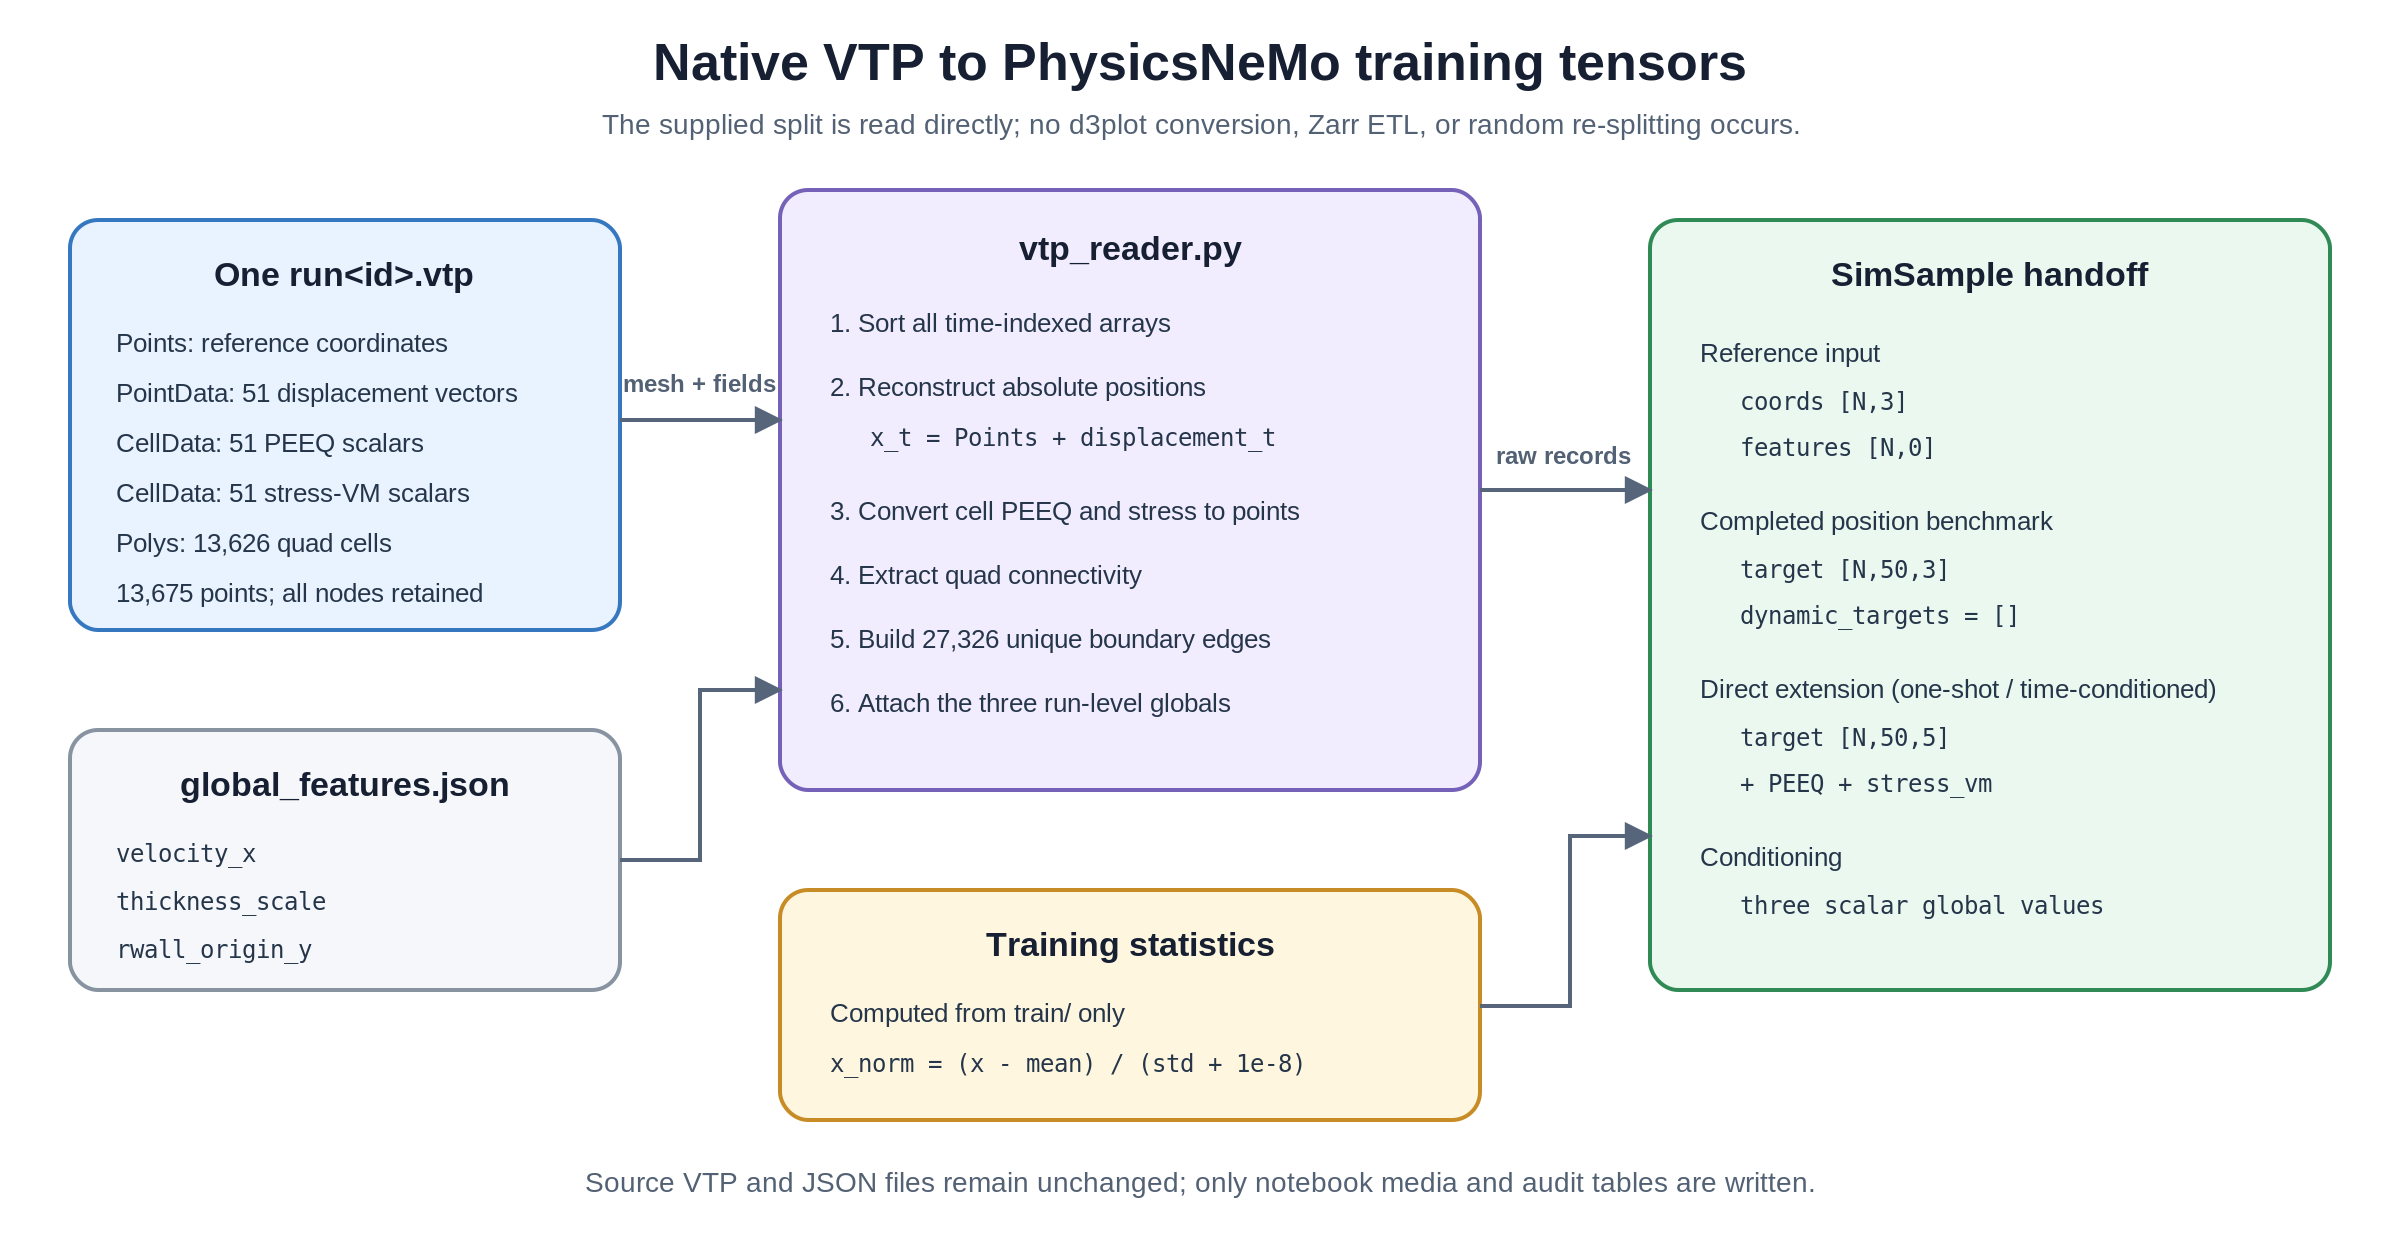

`load_vtp_file` reconstructs native-space positions, extracts quad connectivity, converts PEEQ
and stress from cells to points, and removes the `cell_` prefix after conversion. Normalization
occurs later in `CrashBaseDataset`; it is not applied by the VTP reader.


In [8]:
position_history, mesh_connectivity, reader_point_data = load_vtp_file(str(sample_path))
unique_edges = build_edges_from_mesh_connectivity(mesh_connectivity)
reader_peeq_names = names_by_time(reader_point_data, "effective_plastic_strain_t")
reader_stress_names = names_by_time(reader_point_data, "stress_vm_t")

assert position_history.shape == (51, 13675, 3)
assert len(mesh_connectivity) == 13626 and {len(cell) for cell in mesh_connectivity} == {4}
assert len(unique_edges) == 27326
assert len(reader_peeq_names) == len(reader_stress_names) == 51
assert np.allclose(position_history[0], reference)
assert np.allclose(position_history[1], reference + displacement[1])
assert all(not name.startswith("cell_") for name in reader_peeq_names + reader_stress_names)

reader_contract = pd.DataFrame([
    ["absolute positions", tuple(position_history.shape), "coords"],
    ["quad connectivity", (len(mesh_connectivity), 4), "mesh connectivity"],
    ["unique perimeter edges", (len(unique_edges), 2), "src / dst"],
    ["point PEEQ history", (len(reader_peeq_names), raw_mesh.n_points), "optional dynamic target"],
    ["point stress-VM history", (len(reader_stress_names), raw_mesh.n_points), "optional dynamic target"],
    ["point thickness", tuple(np.asarray(reader_point_data["thickness"]).shape), "available but constant zero"],
], columns=["reader result", "shape", "downstream role"])
display(reader_contract)

raw_peeq_final = np.asarray(raw_mesh.cell_data[peeq_cell_names[-1]], dtype=np.float64)
raw_stress_final = np.asarray(raw_mesh.cell_data[stress_cell_names[-1]], dtype=np.float64)
reader_peeq_final = np.asarray(reader_point_data[reader_peeq_names[-1]], dtype=np.float64)
reader_stress_final = np.asarray(reader_point_data[reader_stress_names[-1]], dtype=np.float64)
support_conversion = pd.DataFrame([
    ["PEEQ", raw_peeq_final.mean(), raw_peeq_final.max(), reader_peeq_final.mean(), reader_peeq_final.max()],
    ["stress VM", raw_stress_final.mean(), raw_stress_final.max(), reader_stress_final.mean(), reader_stress_final.max()],
], columns=["field at t=0.250 s", "cell mean", "cell max", "point mean", "point max"])
display(support_conversion)


,reader result,shape,downstream role
0,absolute positions,"(51, 13675, 3)",coords
1,quad connectivity,"(13626, 4)",mesh connectivity
2,unique perimeter edges,"(27326, 2)",src / dst
3,point PEEQ history,"(51, 13675)",optional dynamic target
4,point stress-VM history,"(51, 13675)",optional dynamic target
5,point thickness,"(13675,)",available but constant zero


,field at t=0.250 s,cell mean,cell max,point mean,point max
0,PEEQ,0.006487,0.487254,0.006495,0.429461
1,stress VM,0.078978,0.500262,0.078781,0.413705


## 7. Exact training-tensor contracts

Position statistics are computed from `train/` and loaded unchanged for validation and inference:

$$\widetilde{\mathbf{x}}_t=(\mathbf{x}_t-\boldsymbol\mu_x)/(\boldsymbol\sigma_x+10^{-8}).$$

State 0 becomes the reference input. States 1 through 50 become the prediction target. Global
values are stacked in configured order and passed without normalization. PEEQ and stress also
remain in their source scale when selected as dynamic targets by the direct models; a combined
five-channel loss therefore mixes standardized position with source-scale scalar fields.


In [9]:
pos_mean = np.asarray(node_stats["pos_mean"], dtype=np.float64)
pos_std = np.asarray(node_stats["pos_std"], dtype=np.float64)
normalized_positions = (position_history - pos_mean[None, None, :]) / (pos_std[None, None, :] + 1e-8)

coords = normalized_positions[0]
empty_features = np.zeros((raw_mesh.n_points, 0), dtype=np.float32)
position_target = normalized_positions[1:].transpose(1, 0, 2)
reader_peeq = np.stack([reader_point_data[name] for name in reader_peeq_names])
reader_stress = np.stack([reader_point_data[name] for name in reader_stress_names])
five_channel_target = np.concatenate([
    position_target,
    reader_peeq[1:].T[:, :, None],
    reader_stress[1:].T[:, :, None],
], axis=2)
global_feature_order = ["velocity_x", "thickness_scale", "rwall_origin_y"]
run_globals = np.asarray([global_records["run1"][name] for name in global_feature_order], dtype=np.float32)

assert coords.shape == (13675, 3)
assert empty_features.shape == (13675, 0)
assert position_target.shape == (13675, 50, 3)
assert five_channel_target.shape == (13675, 50, 5)
assert run_globals.shape == (3,)

tensor_contract = pd.DataFrame([
    ["coords", tuple(coords.shape), "normalized reference positions", "all three models"],
    ["features", tuple(empty_features.shape), "no static point channels", "Notebook2 position demo"],
    ["node_target", tuple(position_target.shape), "50 normalized future positions", "Notebook2 position demo"],
    ["node_target", tuple(five_channel_target.shape), "position + PEEQ + stress", "one-shot / time-conditioned extension"],
    ["global_features", tuple(run_globals.shape), f"{global_feature_order} = {run_globals.tolist()}", "raw context conditioning"],
], columns=["SimSample field", "shape", "content", "scope"])
display(tensor_contract)

statistics = pd.DataFrame({
    "position mean": node_stats["pos_mean"],
    "position std": node_stats["pos_std"],
    "normalized velocity mean": node_stats["norm_vel_mean"],
    "normalized velocity std": node_stats["norm_vel_std"],
    "normalized acceleration mean": node_stats["norm_acc_mean"],
    "normalized acceleration std": node_stats["norm_acc_std"],
}, index=["x", "y", "z"]).T
display(statistics)
print("Feature statistics:", feature_stats)


,SimSample field,shape,content,scope
0,coords,"(13675, 3)",normalized reference positions,all three models
1,features,"(13675, 0)",no static point channels,Notebook2 position demo
2,node_target,"(13675, 50, 3)",50 normalized future positions,Notebook2 position demo
3,node_target,"(13675, 50, 5)",position + PEEQ + stress,one-shot / time-conditioned extension
4,global_features,"(3,)","['velocity_x', 'thickness_scale', 'rwall_origi...",raw context conditioning


,x,y,z
position mean,-30.405893,4.170485,1.269509
position std,105.202853,743.861227,60.722303
normalized velocity mean,-4.947746,0.033394,0.076892
normalized velocity std,7.598037,0.275538,0.685295
normalized acceleration mean,73.356348,-0.010721,-0.130195
normalized acceleration std,345.720312,16.440300,152.939971


Feature statistics: {'feature_mean': [], 'feature_std': []}


## 8. Static, dynamic, and global quantities

Field location and time dependence determine how the recipe exposes each quantity. Cell-to-point
conversion is an interpolation step; converted point values are not identical to the original
cell values.


| Source quantity | Support | Time behavior | Recipe role | Configured name |
|---|---|---|---|---|
| Points | point | static | reference geometry | `coords` |
| `displacement_t*` | point | time series | reconstruct absolute positions | position target |
| `thickness` | point | static | excluded from the Notebook2 demo | static feature (unused) |
| `cell_effective_plastic_strain_t*` | cell → point | time series | optional scalar target | `effective_plastic_strain` |
| `cell_stress_vm_t*` | cell → point | time series | optional scalar target | `stress_vm` |
| `velocity_x` | run-level JSON | static per run | global conditioning | global token |
| `thickness_scale` | run-level JSON | static per run | global conditioning | global token |
| `rwall_origin_y` | run-level JSON | static per run | global conditioning | global token |

The preceding audit measures the number of stored states and verifies that the supplied point
`thickness` array is constant. The Notebook2 demonstration uses the reference geometry and three
run-level conditions; PEEQ and stress remain available for a separate five-channel model.

## 9. Ground-truth crash sequence

The animation uses the reconstructed VTP positions and point-interpolated PEEQ. Both panels use
fixed camera limits and fixed color scales across all 51 source states. Rendering subsamples
points only; the data audit and tensor construction retain the full mesh.


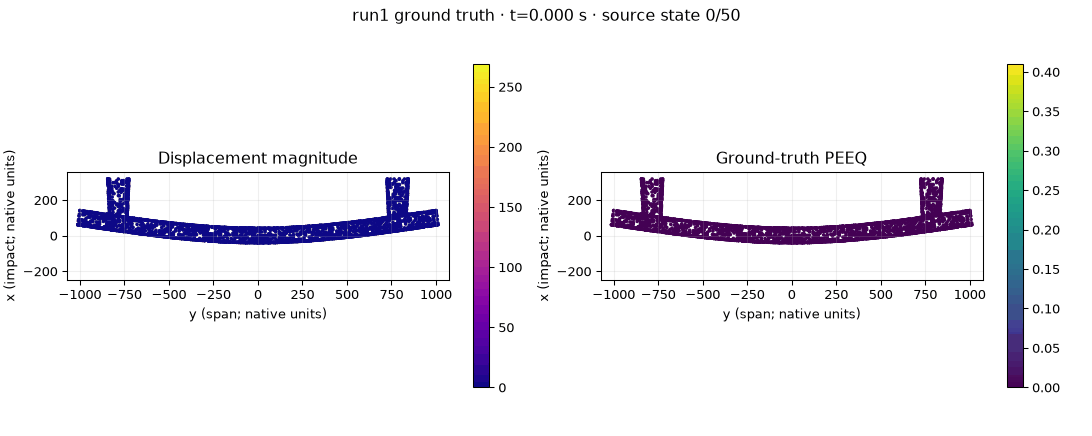

In [10]:
with TemporaryDirectory() as temporary_directory:
    animation_path = Path(temporary_directory) / "run1_ground_truth_displacement_peeq.gif"
    node_ids = np.sort(np.random.default_rng(11).choice(raw_mesh.n_points, 3200, replace=False))
    span = positions[:, node_ids, 1]
    impact = positions[:, node_ids, 0]
    x_margin = 0.03 * (span.max() - span.min())
    y_margin = 0.08 * (impact.max() - impact.min())
    disp_max = float(displacement_magnitude[:, node_ids].max()) or 1.0
    peeq_max = float(peeq_point[:, node_ids].max()) or 1.0

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), dpi=95)
    panels = [
        (displacement_magnitude, "Displacement magnitude", "plasma", disp_max),
        (peeq_point, "Ground-truth PEEQ", "viridis", peeq_max),
    ]
    scatters = []
    for ax, (values, title, cmap, vmax) in zip(axes, panels):
        scatter = ax.scatter(span[0], impact[0], c=values[0, node_ids], s=3,
                             cmap=cmap, vmin=0, vmax=vmax)
        ax.set(xlim=(span.min() - x_margin, span.max() + x_margin),
               ylim=(impact.min() - y_margin, impact.max() + y_margin),
               xlabel="y (span; native units)", ylabel="x (impact; native units)",
               title=title)
        ax.set_aspect("equal")
        ax.grid(alpha=0.2)
        fig.colorbar(scatter, ax=ax, shrink=0.82)
        scatters.append((scatter, values))
    heading = fig.suptitle("")
    fig.tight_layout()

    def update(frame):
        offsets = np.c_[span[frame], impact[frame]]
        for scatter, values in scatters:
            scatter.set_offsets(offsets)
            scatter.set_array(values[frame, node_ids])
        heading.set_text(f"run1 ground truth · t={times[frame]:.3f} s · source state {frame}/50")
        return tuple(scatter for scatter, _ in scatters)

    movie = animation.FuncAnimation(fig, update, frames=range(51), interval=100, blit=False)
    movie.save(animation_path, writer=animation.PillowWriter(fps=10), dpi=95)
    animation_bytes = animation_path.read_bytes()
    plt.close(fig)

display(Image(data=animation_bytes))


## 10. Downstream handoff

| Consumer | Sample type | Local input | Target produced from Notebook0 data |
|---|---|---:|---:|
| Notebook2 one-shot demonstration | `all_time_steps` | `[N,3]` | `[N,50,3]` |
| Time-conditioned recipe configuration | `one_time_step` | `[N,4]` including model time | `[N,3]` per query |
| Autoregressive recipe configuration | `all_time_steps` | `[N,3]` normalized velocity | `[N,50,3]` |
| Direct five-channel one-shot / time-conditioned extension | method-dependent | reference position + model time when applicable | position + PEEQ + stress |

The native VTP files remain the source of truth for every downstream run. Saved statistics belong
to a training lineage and must remain paired with its checkpoints during validation and inference.
The current autoregressive wrapper predicts three position channels; adding PEEQ and stress requires
extending its recurrent output/state contract rather than changing `out_dim` alone.


## 11. Data assumptions and limitations

- The five files in `test/` are byte-identical to `validation/`; they do not provide an independent test estimate.
- VTP metadata do not declare physical units. Coordinates and displacement are reported as native length units; stress and PEEQ retain source units.
- The point array `thickness` is zero in all 134 unique files and is excluded from the completed models. `thickness_scale` remains available as a run-level global value.
- Five reference-geometry variants share identical quad connectivity. Geometry variation is carried by the reference coordinates, not by an additional JSON global.
- PEEQ and stress originate on cells. The recipe interpolates them to points before using them as dynamic targets.
- `load_vtp_file` fixes source state 0 to the reference coordinates and reconstructs later states from displacement.
- Time-conditioned model time $k/50$ is a dimensionless query coordinate; target physical time is $(k+1)\,0.005\,\mathrm{s}$.
- A five-channel loss needs explicit attention to target scaling or weighting because position is standardized while PEEQ and stress are not.
- The Notebook2 demonstration and embedded reference comparison predict position only; source-field availability is not evidence of predicted stress or plastic strain.


## 12. Conclusions

The supplied dataset is internally consistent across 129 training and five validation simulations:
every file has the same quad topology, one of five reference geometries, 51 synchronized
displacement/PEEQ/stress states, finite final arrays, and a matching global-feature entry.
Validation membership is preserved, and the duplicate test directory is treated as a validation alias.

PhysicsNeMo reconstructs `[51,13675,3]` absolute positions, converts the two cell histories to
point histories, and builds 27,326 unique edges. The training datapipe then applies train-derived
position statistics and emits the position-only `[N,50,3]` target used by the Notebook2 demonstration,
while the same VTPs retain the two physical fields required for a direct one-shot or
time-conditioned five-channel extension.

**Sources:** native VTP files, `global_features.json`, mounted `vtp_reader.py` and `datapipe.py`,
and the normalization statistics saved with the completed one-shot training lineage.
